# Impact of parameter perturbations


F2 -10%:
SAD: [0.1665 0.1647 0.1776 0.2162 0.1417 0.1333]
λ₁: 0.7977 (change: -0.0009)
Euclidean distance from original SAD: 0.0007

F3 -10%:
SAD: [0.1643 0.1634 0.1772 0.2169 0.143  0.1352]
λ₁: 0.7931 (change: -0.0054)
Euclidean distance from original SAD: 0.0043

F4 -10%:
SAD: [0.1628 0.1625 0.1769 0.2174 0.1439 0.1365]
λ₁: 0.7902 (change: -0.0083)
Euclidean distance from original SAD: 0.0067

F5 -10%:
SAD: [0.1654 0.1641 0.1774 0.2165 0.1424 0.1342]
λ₁: 0.7955 (change: -0.0031)
Euclidean distance from original SAD: 0.0024

F6 -10%:
SAD: [0.1658 0.1643 0.1775 0.2164 0.1422 0.1339]
λ₁: 0.7962 (change: -0.0024)
Euclidean distance from original SAD: 0.0019

S1 -10%:
SAD: [0.1711 0.1562 0.1727 0.2155 0.1449 0.1397]
λ₁: 0.7780 (change: -0.0206)
Euclidean distance from original SAD: 0.0133

S2 -10%:
SAD: [0.1687 0.1709 0.1698 0.2117 0.1421 0.1369]
λ₁: 0.7789 (change: -0.0196)
Euclidean distance from original SAD: 0.0116

S3 -10%:
SAD: [0.1684 0.1694 0.1857 0.2068 0.1379 0.1318]
λ₁: 0.7845

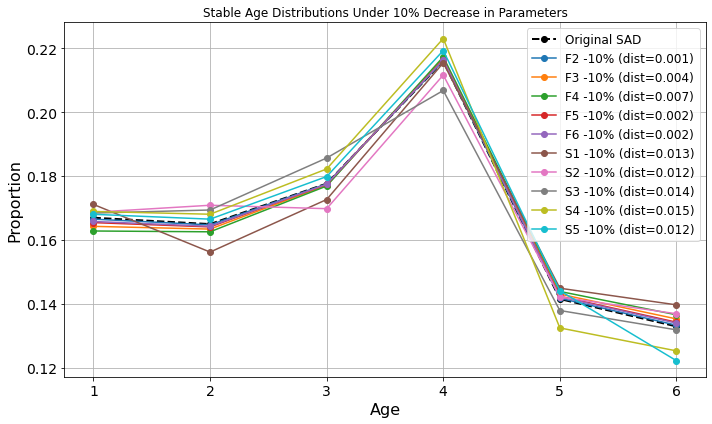

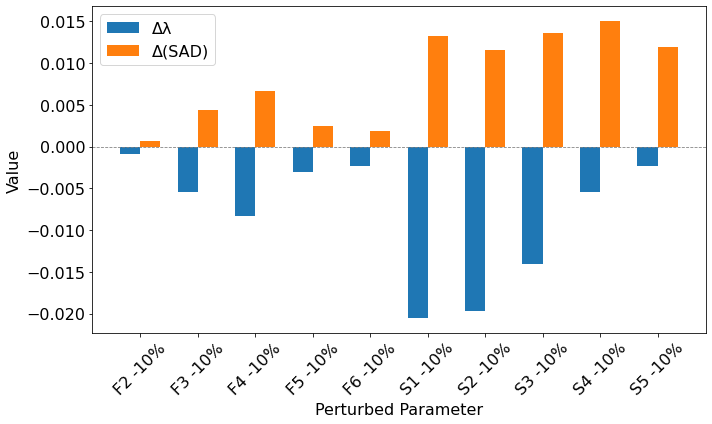

In [11]:
import numpy as np
from scipy.linalg import eig
from numpy.linalg import norm
import matplotlib.pyplot as plt

# === Original Leslie Matrix ===
L_original = np.array([
    [0.    , 0.036 , 0.204 , 0.255 , 0.144 , 0.118 ],
    [0.789 , 0.    , 0.    , 0.    , 0.    , 0.    ],
    [0.    , 0.860 , 0.    , 0.    , 0.    , 0.    ],
    [0.    , 0.    , 0.971 , 0.    , 0.    , 0.    ],
    [0.    , 0.    , 0.    , 0.523 , 0.    , 0.    ],
    [0.    , 0.    , 0.    , 0.    , 0.750 , 0.    ]
])

# === Functions ===
def get_SAD_and_lambda(L):
    vals, vecs = eig(L)
    idx = np.argmax(np.real(vals))
    lambda1 = np.real(vals[idx])
    v = np.real(vecs[:, idx])
    SAD = v / v.sum()
    return SAD, lambda1

# === Original SAD and λ₁ ===
sad_original, lambda_original = get_SAD_and_lambda(L_original)

# === Define perturbations (10% decrease) ===
delta = -0.10
perturbations = {
    'F2 -10%': (0, 1),
    'F3 -10%': (0, 2),
    'F4 -10%': (0, 3),
    'F5 -10%': (0, 4),
    'F6 -10%': (0, 5),
    'S1 -10%': (1, 0),
    'S2 -10%': (2, 1),
    'S3 -10%': (3, 2),
    'S4 -10%': (4, 3),
    'S5 -10%': (5, 4),
}

# === Compute SADs, λ₁s, and distances ===
results = {}
for label, (i, j) in perturbations.items():
    L_perturbed = L_original.copy()
    L_perturbed[i, j] *= (1 + delta)
    sad_new, lambda_new = get_SAD_and_lambda(L_perturbed)
    dist = norm(sad_new - sad_original)
    results[label] = {
        'sad': sad_new,
        'lambda': lambda_new,
        'distance': dist
    }
    print(f"\n{label}:")
    print(f"SAD: {np.round(sad_new, 4)}")
    print(f"λ₁: {lambda_new:.4f} (change: {lambda_new - lambda_original:+.4f})")
    print(f"Euclidean distance from original SAD: {dist:.4f}")

# === Plot SADs ===
ages = np.arange(1, 7)
plt.figure(figsize=(10, 6))
plt.plot(ages, sad_original, 'k--o', linewidth=2, label='Original SAD')
for label, result in results.items():
    plt.plot(ages, result['sad'], marker='o', label=f"{label} (dist={result['distance']:.3f})")
plt.xlabel('Age', fontsize=16)
plt.ylabel('Proportion', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Stable Age Distributions Under 10% Decrease in Parameters')
plt.grid(True)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

# === Bar Plot: λ₁ Change and SAD Distance ===
labels = list(results.keys())
lambda_changes = [results[l]['lambda'] - lambda_original for l in labels]
distances = [results[l]['distance'] for l in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, lambda_changes, width, label='Δλ')
plt.bar(x + width/2, distances, width, label='Δ(SAD)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)


plt.xticks(x, labels, rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Perturbed Parameter', fontsize=16)
plt.ylabel('Value', fontsize=16)
#plt.title('Effect of 10% Parameter Reductions on λ and SAD', fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("lambda_sad_plot.pdf", bbox_inches="tight")
plt.savefig("lambda_sad_plot.png", dpi=300)
plt.show()

# Scenarios A-E

Base λ: 0.7985
Scenario A λ: 0.7832
Scenario B λ: 0.7705
Scenario C λ: 0.7527
Scenario D λ: 0.7149
Scenario E λ: 0.8177

Base Stable Age Distribution:
 Age 1: 0.1670
 Age 2: 0.1650
 Age 3: 0.1777
 Age 4: 0.2160
 Age 5: 0.1415
 Age 6: 0.1329

Scenario A Stable Age Distribution:
 Age 1: 0.1731
 Age 2: 0.1743
 Age 3: 0.1914
 Age 4: 0.2373
 Age 5: 0.1268
 Age 6: 0.0971

Scenario B Stable Age Distribution:
 Age 1: 0.1530
 Age 2: 0.1566
 Age 3: 0.1748
 Age 4: 0.2204
 Age 5: 0.1496
 Age 6: 0.1456

Scenario C Stable Age Distribution:
 Age 1: 0.1579
 Age 2: 0.1655
 Age 3: 0.1891
 Age 4: 0.2439
 Age 5: 0.1356
 Age 6: 0.1081

Scenario D Stable Age Distribution:
 Age 1: 0.1556
 Age 2: 0.1717
 Age 3: 0.2066
 Age 4: 0.2245
 Age 5: 0.1314
 Age 6: 0.1103

Scenario E Stable Age Distribution:
 Age 1: 0.1642
 Age 2: 0.1664
 Age 3: 0.1837
 Age 4: 0.2182
 Age 5: 0.1395
 Age 6: 0.1280


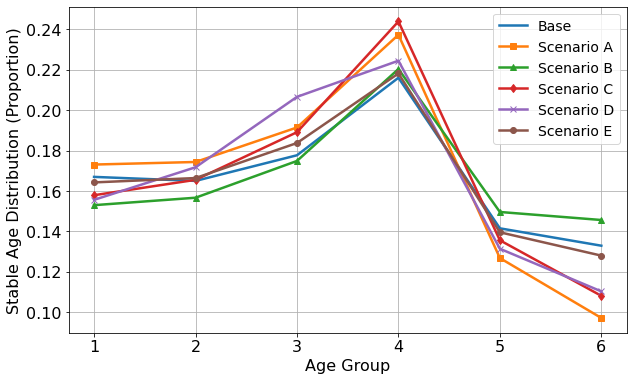

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Original Leslie matrix
L_base = np.array([
    [0.0,   0.036, 0.204, 0.255,  0.144, 0.118],
    [0.789, 0.0,   0.0,   0.0,   0.0,   0.0],
    [0.0,   0.860, 0.0,   0.0,   0.0,   0.0],
    [0.0,   0.0,   0.971, 0.0,   0.0,   0.0],
    [0.0,   0.0,   0.0,   0.523, 0.0,   0.0],
    [0.0,   0.0,   0.0,   0.0,   0.750, 0.0]
])

def dominant_eigenvalue(L):
    eigvals = np.linalg.eigvals(L)
    return np.max(np.real(eigvals))

def stable_age_distribution(L):
    eigvals, eigvecs = np.linalg.eig(L)
    # Find index of dominant eigenvalue (real part)
    dominant_index = np.argmax(np.real(eigvals))
    # Corresponding eigenvector
    w = np.real(eigvecs[:, dominant_index])
    # Normalize to sum to 1
    sad = w / np.sum(w)
    return sad

# Reduction factor (20% decrease)
delta = -0.2

# Scenario A: Reduced survival of older fish
L_A = L_base.copy()
L_A[4, 3] *= (1+delta)   # S4→S5 reduced
L_A[5, 4] *= (1+delta)   # S5→S6+ reduced

# Scenario B: Reduced fecundity of main reproductive fish 
L_B = L_base.copy()
L_B[0, 2] *= (1+delta) #20% decrease
L_B[0, 3] *= (1+delta) # 20% decrease


# Scenario C: Combined reduction of fecundity and survival
L_C = L_base.copy()
L_C[4, 3] *= (1+delta)
L_C[5, 4] *= (1+delta)
L_C[0, 2] *= (1+delta)
L_C[0, 3] *= (1+delta)

# Scenario D: Loss of reproductive contribution from older fish
L_D = L_base.copy()
L_D[3, 2] *= (1+delta)
L_D[4, 3] *= (1+delta)
L_D[5, 4] *= (1+delta)

L_D[0, 2] *= (1+delta)
L_D[0, 3] *= (1+delta)
L_D[0, 4] *= (1+delta)
L_D[0, 5] *= (1+delta)

# Amplification factor (5% increase)
delta1 = 0.05


# Scenario E: Increased juvenile survival
L_E = L_base.copy()
L_E[1, 0] *= (1+delta1) # 5% increase  
L_E[2, 1] *= (1+delta1) # 5% increase  

# Calculate dominant eigenvalues
lambda_base = dominant_eigenvalue(L_base)
lambda_A = dominant_eigenvalue(L_A)
lambda_B = dominant_eigenvalue(L_B)
lambda_C = dominant_eigenvalue(L_C)
lambda_D = dominant_eigenvalue(L_D)
lambda_E = dominant_eigenvalue(L_E)

print(f"Base λ: {lambda_base:.4f}")
print(f"Scenario A λ: {lambda_A:.4f}")
print(f"Scenario B λ: {lambda_B:.4f}")
print(f"Scenario C λ: {lambda_C:.4f}")
print(f"Scenario D λ: {lambda_D:.4f}")
print(f"Scenario E λ: {lambda_E:.4f}")

# Calculate stable age distributions
sad_base = stable_age_distribution(L_base)
sad_A = stable_age_distribution(L_A)
sad_B = stable_age_distribution(L_B)
sad_C = stable_age_distribution(L_C)
sad_D = stable_age_distribution(L_D)
sad_E = stable_age_distribution(L_E)

# Print SADs
def print_sad(name, sad):
    print(f"\n{name} Stable Age Distribution:")
    for i, val in enumerate(sad, start=1):
        print(f" Age {i}: {val:.4f}")

print_sad("Base", sad_base)
print_sad("Scenario A", sad_A)
print_sad("Scenario B", sad_B)
print_sad("Scenario C", sad_C)
print_sad("Scenario D", sad_D)
print_sad("Scenario E", sad_E)

# Plot SADs
ages = np.arange(1, len(sad_base) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ages, sad_base, '-', linewidth=2.5, label='Base')
plt.plot(ages, sad_A, 's-',  linewidth=2.5, label='Scenario A')
plt.plot(ages, sad_B, '^-',  linewidth=2.5, label='Scenario B')
plt.plot(ages, sad_C, 'd-',  linewidth=2.5, label='Scenario C')
plt.plot(ages, sad_D, 'x-',  linewidth=2.5, label='Scenario D')
plt.plot(ages, sad_E, 'o-',  linewidth=2.5, label='Scenario E')

plt.xlabel('Age Group', fontsize=16)
plt.ylabel('Stable Age Distribution (Proportion)',fontsize=16)
#plt.title('Stable Age Distribution vs Age for Different Scenarios',fontsize=16)
plt.xticks(ages, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.savefig("Leslie_scenarios.png", dpi=300)
plt.savefig("Leslie_scenarios.pdf", bbox_inches="tight")
plt.show()